In [1]:
import pandas as pd
import numpy as np
import pickle
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import (
    confusion_matrix, f1_score, recall_score,
    precision_score, classification_report
)

In [2]:
df = pd.read_csv('dataset.csv', header=None)

# Kiểm tra số lượng cột và đảm bảo rằng cột cuối cùng là nhãn
num_columns = df.shape[1]
df = df.rename(columns={num_columns-1: 'label'})


In [3]:
X = df.iloc[:, :-1]
y = df['label']


In [4]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)


In [5]:
x_train, x_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Huấn luyện mô hình SVM
svm = SVC(C=10, gamma=0.1, kernel='rbf')
svm.fit(x_train, y_train)


SVC(C=10, gamma=0.1)

In [6]:
y_pred = svm.predict(x_test)

In [7]:
cf_matrix = confusion_matrix(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='micro')
recall = recall_score(y_test, y_pred, average='micro')
precision = precision_score(y_test, y_pred, average='micro')


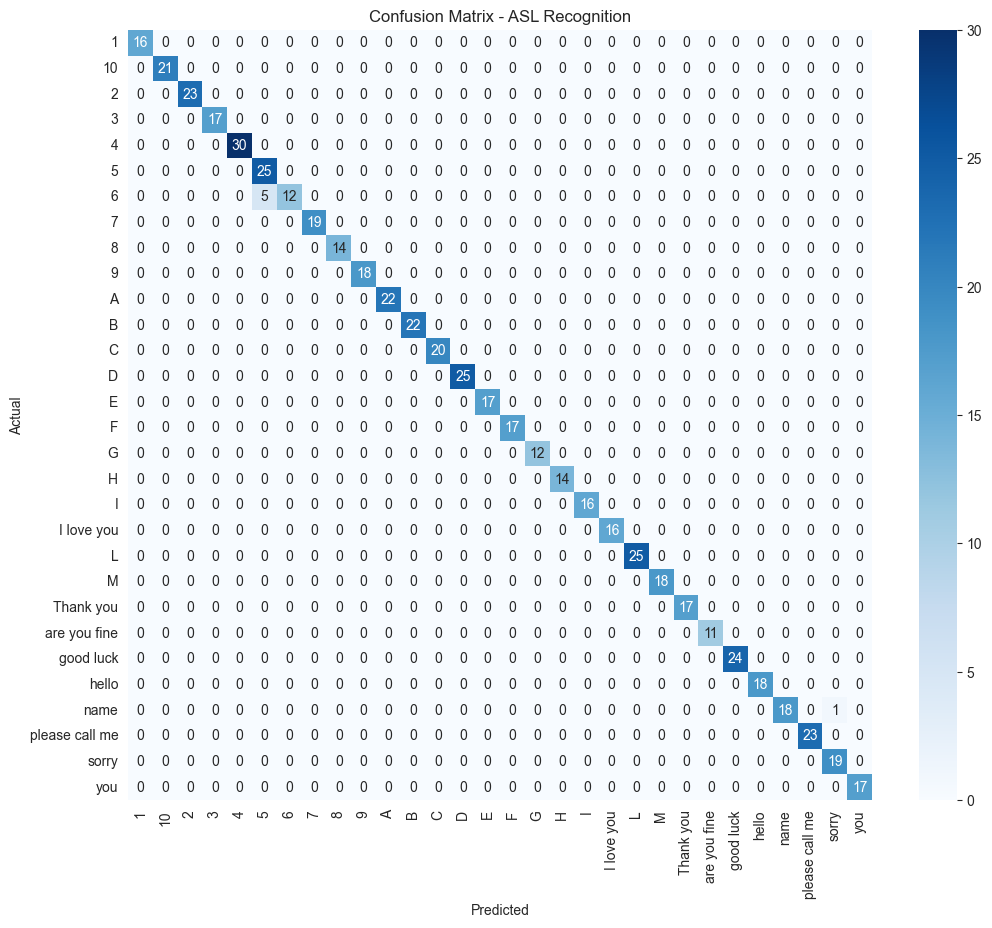

In [8]:
label_names = le.classes_
plt.figure(figsize=(12, 10))
sns.heatmap(cf_matrix, annot=True, fmt='g', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.title('Confusion Matrix - ASL Recognition')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [9]:
with open('model.pkl', 'wb') as f:
    pickle.dump((svm, le), f)